In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
df_train = pd.read_csv('/kaggle/input/original-depresive/train_df_depressive.csv')
df_test = pd.read_csv('/kaggle/input/original-depresive/test_df_depressive.csv')

In [3]:
len(df_train)

2739

In [4]:
df_test['label'].value_counts()

label
non_depressive    897
depressive        278
Name: count, dtype: int64

In [5]:
from sklearn.utils import resample

In [6]:
# Separate the majority and minority classes
df_majority = df_train[df_train.label == "non_depressive"]
df_minority = df_train[df_train.label == "depressive"]

# Perform random oversampling on the minority class
df_minority_oversampled = resample(df_minority,
                                   replace=True,  # sample with replacement
                                   n_samples=len(df_majority),  # to match majority class
                                   random_state=42)  # for reproducibility

# Combine majority class with oversampled minority class
df_oversampled = pd.concat([df_majority, df_minority_oversampled])

# Shuffle the DataFrame to mix the oversampled minority class with the majority class
df_oversampled = df_oversampled.sample(frac=1, random_state=42).reset_index(drop=True)

# Display the new DataFrame
print(df_oversampled)

      Unnamed: 0                                               text  \
0           2903  আবার বিজেপি কর্মী খুন ছিঃর উন্নয়ন বাহিনীর হাত...   
1           1287  ১৭১ দিন , প্রতিহিংসার কারাগারে বন্দী আপোষহীন দ...   
2           2027  স্বপ্নগুলো ধূলিসাৎ হয়ে যায় আর কষ্টগুলি মিথ্য...   
3           3482  পৃথিবীতে নিজেকে গড়ে তোলার জন্য অনেক বই পড়ার ...   
4            260  মাননীয়া মুখ্যমন্ত্রীর দলের তৈরি বোমাও এখন বাং...   
...          ...                                                ...   
4061        3403  রাসূল সা বলেন , জান্নাতের বাগানগুলোতে তোমরা ফল...   
4062          60        শুভ রাত্রি সকলকে ভালো থাকো সুস্থ থাকো সকলে    
4063         696   ছবি নয় , চরিত্র এডিট করো দুনিয়া আখেরাত উজ্জ...   
4064         960  সিলেটে পুলিশ ও মেজিস্ট্রেটের উপস্থিতিতে কেন্দ্...   
4065        2609  ছোটবেলায় জ্বর হলে বাজার থেকে বাবা আনারস কিনে ...   

               label  
0         depressive  
1         depressive  
2     non_depressive  
3     non_depressive  
4         depressive  
...      

In [7]:
df_train = df_oversampled

In [8]:
df_train.label.value_counts()

label
depressive        2033
non_depressive    2033
Name: count, dtype: int64

In [9]:
pip install transformers torch scikit-learn pandas


Note: you may need to restart the kernel to use updated packages.


In [10]:
print("Information of TrainSet dataframe....")
df_train.info()

Information of TrainSet dataframe....
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4066 entries, 0 to 4065
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  4066 non-null   int64 
 1   text        4066 non-null   object
 2   label       4066 non-null   object
dtypes: int64(1), object(2)
memory usage: 95.4+ KB


In [11]:
print("Information of TrainSet dataframe....")
df_test.info()

Information of TrainSet dataframe....
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1175 entries, 0 to 1174
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1175 non-null   int64 
 1   text        1175 non-null   object
 2   label       1175 non-null   object
dtypes: int64(1), object(2)
memory usage: 27.7+ KB


In [12]:
import re

def text_to_word_list(text):
    text = text.split()
    return text

def replace_strings(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           u"\u00C0-\u017F"          #latin
                           u"\u2000-\u206F"          #generalPunctuations
                               
                           "]+", flags=re.UNICODE)
    english_pattern=re.compile('[a-zA-Z0-9]+', flags=re.I)
    #latin_pattern=re.compile('[A-Za-z\u00C0-\u00D6\u00D8-\u00f6\u00f8-\u00ff\s]*',)
    
    text=emoji_pattern.sub(r'', text)
    text=english_pattern.sub(r'', text)

    return text

def remove_punctuations(my_str):
    # define punctuation
    punctuations = '''````£|¢|Ñ+-*/=EROero৳০১২৩৪৫৬৭৮৯012–34567•89।!()-[]{};:'"“\’,<>./?@#$%^&*_~‘—॥”‰🤣⚽️✌�￰৷￰'''
    
    no_punct = ""
    for char in my_str:
        if char not in punctuations:
            no_punct = no_punct + char

    # display the unpunctuated string
    return no_punct



def joining(text):
    out=' '.join(text)
    return out

def preprocessing(text):
    out=remove_punctuations(replace_strings(text))
    return out

In [13]:
df_train['text'] = df_train.text.apply(lambda x: preprocessing(str(x)))
df_test['text'] = df_test.text.apply(lambda x: preprocessing(str(x)))

In [14]:
df_train['text'].iloc[0]

'আবার বিজেপি কর্মী খুন ছিঃর উন্নয়ন বাহিনীর হাতে  মন্দির বাজার এলাকার বাসিন্দা শক্তিপদ সর্দারকে কুপিয়ে মারা হল কিন্তু পুলিশ প্রশাসন চুপ  দ্বিচারিতার কোন পর্যায়ে চলে গেলে একটা সরকার এতটা নির্মম হতে পারে  আমি ওনার পরিবারকে গভীর সমবেদনা জানাই   '

In [15]:
data1 =pd.read_excel('/kaggle/input/bangla-stopwords/stopwords_bangla.xlsx')
stop = data1['words'].tolist()

In [16]:
display(data1)

,Unnamed: 0,words
0,0,অই
1,1,অগত্যা
2,2,অত: পর
3,3,অতএব
4,4,অথচ
...,...,...
727,727,হয়েই
728,728,হয়েছিল
729,729,হয়েছে
730,730,হয়েছেন


In [17]:
def stopwordRemoval(text):    
    x=str(text)
    l=x.split()

    stm=[elem for elem in l if elem not in stop]
    
    out=' '.join(stm)
    
    return str(out)

# df_train['text'] = df_train.text.apply(lambda x: stopwordRemoval(str(x)))
# df_test['text'] = df_test.text.apply(lambda x: stopwordRemoval(str(x)))

In [18]:
df_train.text.iloc[0]

'আবার বিজেপি কর্মী খুন ছিঃর উন্নয়ন বাহিনীর হাতে  মন্দির বাজার এলাকার বাসিন্দা শক্তিপদ সর্দারকে কুপিয়ে মারা হল কিন্তু পুলিশ প্রশাসন চুপ  দ্বিচারিতার কোন পর্যায়ে চলে গেলে একটা সরকার এতটা নির্মম হতে পারে  আমি ওনার পরিবারকে গভীর সমবেদনা জানাই   '

In [19]:
df_test.text.iloc[0]

'ভাগ্যের কোনো ফ্যামিলি  মা বাবা নাই সে এতিম  তাই যখন তখন যেখানে সেখানে অন্যের লাইফে সমস্যা সৃষ্টি করতে মায়া দেখায় না  '

In [20]:
pip install fastText

Note: you may need to restart the kernel to use updated packages.


In [21]:
import pandas as pd
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import fasttext

# Load pre-trained FastText model for Bangla
# Make sure to replace 'cc.bn.300.bin' with the path to your FastText model file
model = fasttext.load_model('/kaggle/input/fasttext-bangla/cc.bn.300.bin')

def get_embeddings(text_list):
    embeddings = []
    for text in text_list:
        embedding = model.get_sentence_vector(text)
        embeddings.append(embedding)
    return np.array(embeddings)

2024-06-23 11:46:07.639697: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-23 11:46:07.639802: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-23 11:46:07.762454: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [22]:
# Get embeddings for training and testing data
X_train = get_embeddings(df_train['text'].tolist())
X_test = get_embeddings(df_test['text'].tolist())

# Encode labels
le = LabelEncoder()
y_train = le.fit_transform(df_train['label'])
y_test = le.transform(df_test['label'])

# One-hot encode the labels
y_train = to_categorical(y_train, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

In [23]:
X_train.shape

(4066, 300)

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Bidirectional, LSTM, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow import keras

In [25]:
# Define the more generalized CNN + BiLSTM model
model = Sequential([
    Conv1D(100, 3, activation='relu', input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.1)),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 298, 100)       │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 298, 100)       │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 149, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 149, 256)       │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 149, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 38144)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,765,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,034,594 (38.28 MB)

 Trainable params: 10,033,882 (38.28 MB)

 Non-trainable params: 712 (2.78 KB)

In [26]:
# Reshape the data to fit the model
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


In [27]:
X_train_cnn.shape

(4066, 300, 1)

In [28]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 993.8/993.8 kB 19.2 MB/s eta 0:00:0000:01


In [29]:
# import visualkeras

# visualkeras.layered_view(model).show() # display using your system viewer
# # visualkeras.layered_view(model, to_file='output.png') # write to disk
# # visualkeras.layered_view(model, to_file='output.png').show() # write and show

In [30]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks for early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)

# Train the model with callbacks
history = model.fit(X_train_cnn, y_train, epochs=60, batch_size=16, validation_split=0.2,
                    callbacks=[early_stopping, reduce_lr])

Epoch 1/60
204/204 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.6392 - loss: 14.6262 - val_accuracy: 0.5246 - val_loss: 2.6459 - learning_rate: 0.0010
Epoch 2/60
204/204 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7467 - loss: 1.9718 - val_accuracy: 0.5246 - val_loss: 1.2541 - learning_rate: 0.0010
Epoch 3/60
204/204 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7549 - loss: 0.9605 - val_accuracy: 0.5872 - val_loss: 0.8980 - learning_rate: 0.0010
Epoch 4/60
204/204 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7722 - loss: 0.7156 - val_accuracy: 0.8047 - val_loss: 0.6660 - learning_rate: 0.0010
Epoch 5/60
204/204 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7625 - loss: 0.6551 - val_accuracy: 0.6794 - val_loss: 0.7511 - learning_rate: 0.0010
Epoch 6/60
204/204 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7609 - loss: 0.6294 - val_accuracy: 0.8182 - val_loss: 0.6043 - learning_rate: 0.0010
Epoch 7/60
204/204 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7496 - loss: 

In [31]:
loss, accuracy = model.evaluate(X_test_cnn, y_test)
print(f'Accuracy: {accuracy * 100:.2f}%')

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8339 - loss: 0.5478
Accuracy: 81.96%


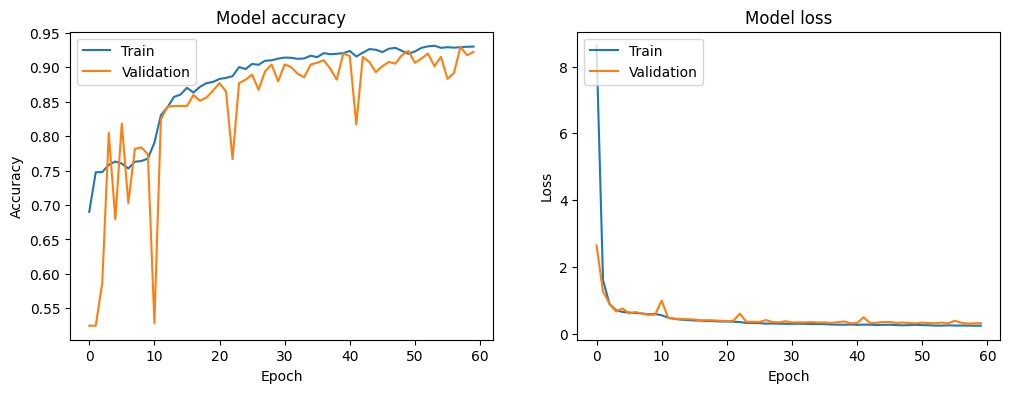

In [32]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
                precision    recall  f1-score   support

    depressive       0.59      0.76      0.67       278
non_depressive       0.92      0.84      0.88       897

      accuracy                           0.82      1175
     macro avg       0.76      0.80      0.77      1175
  weighted avg       0.84      0.82      0.83      1175



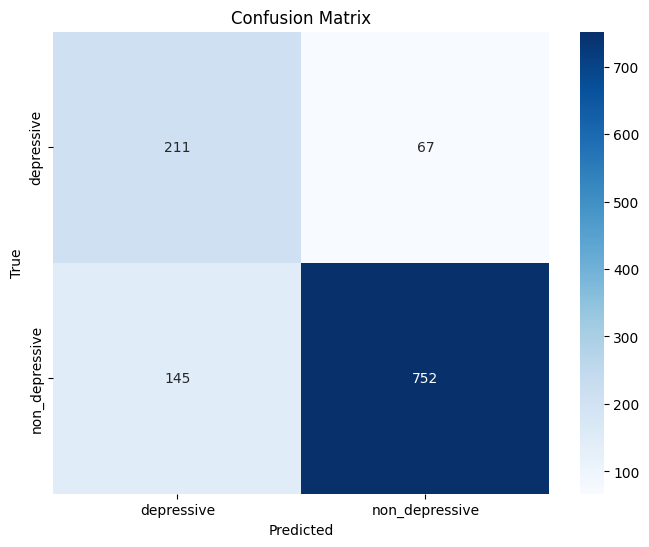

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict the labels for the test set
y_pred = model.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate classification report
report = classification_report(y_true, y_pred_classes, target_names=le.classes_)
print(report)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


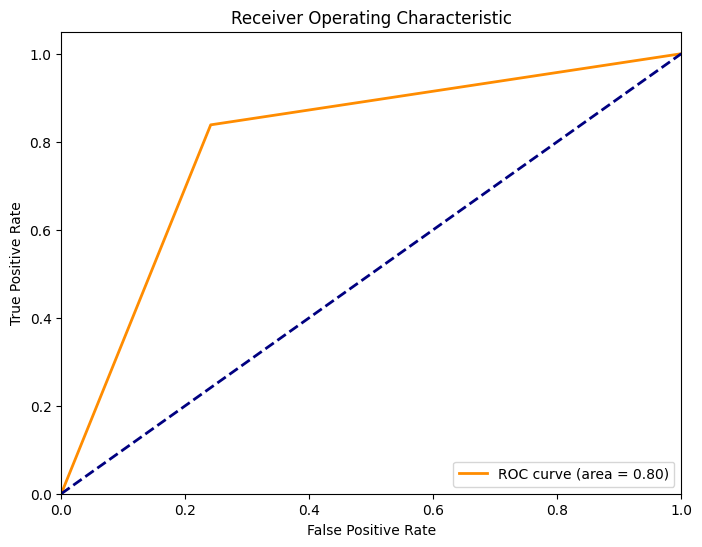

In [34]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}

# Only for the positive class (assuming binary classification)
fpr[1], tpr[1], _ = roc_curve(y_true, y_pred_classes)
roc_auc[1] = auc(fpr[1], tpr[1])

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr[1], tpr[1], color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc[1])
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()
